In [2]:
from dataset import CUBSentences

In [3]:
data = CUBSentences(root_data_dir='/Users/agathe/dev/data', split='train')

In [4]:
sample, length = data[2][0], data[2][1]

In [5]:
print("lenght is ", length)
for i in sample:
    print(data.i2w[str(i)])

lenght is  17
this
bird
has
a
curved
white
bill
,
a
white
belly
,
and
black
primaries
.
<eos>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>


In [6]:
data = CUBSentences(root_data_dir='/Users/agathe/dev/data', split='train', one_hot=True)

In [7]:
data[0][0].shape

torch.Size([32, 1590])

In [44]:
for i in range(10):
    print(data._to_string(data[i][0].numpy()))

a white bird with black tipped wings and a long grey beak . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
this bird has a white chest with a long pointed white beak . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
this bird has a curved white bill , a white belly , and black primaries . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
this white bird has black along the ends of its wings and a pale , long beak . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
this medium sized to large bird has a white belly , breast , head and tail with a long , pointed beak . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
the bird has a long white bill and long black secondaries . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad

In [14]:
from torchvision import transforms, datasets
tx = transforms.Compose([transforms.Resize([64, 64]), transforms.ToTensor()])
image_data = datasets.ImageFolder('/Users/agathe/dev/data/cub/train', transform=tx)
            

In [16]:
image_data[0][0].shape

torch.Size([3, 64, 64])

In [40]:
len(data), len(image_data)

(88550, 8855)

Chaque image est associée à 10 légendes possibles donc le jeu de données final est fabriqué en répliquant 10 fois chaque image.
pour l'indice i on renvoie l'image i//10

In [1]:
from dataset import CUB

dataset = CUB('/Users/agathe/dev/data/')

In [2]:
dataset[0].data['text']

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.]])

In [3]:
from architectures_text import Enc

encoder = Enc(latentDim_w=12,latentDim_z=12,dist='normal')



In [4]:
sample = dataset[0].data['text'].reshape(1,32,1590)

In [5]:
embedding = encoder(sample)
embedding

[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


ModelOutput([('embedding',
              tensor([[-0.0434, -0.3536, -0.0798,  0.3596,  0.2119, -0.2266,  0.2163,  0.2139,
                       -0.1286, -0.2765,  0.2524,  0.2735]], grad_fn=<UnsqueezeBackward0>)),
             ('style_embedding',
              tensor([[-0.0233,  0.0807,  0.2944,  0.2132,  0.1666,  0.1815, -0.4421,  0.1565,
                        0.0705,  0.9135, -0.1494, -0.5910]], grad_fn=<AddmmBackward0>)),
             ('log_covariance',
              tensor([[0.8979, 0.7413, 0.9222, 0.4946, 1.6681, 1.1072, 1.6793, 1.2934, 0.2915,
                       1.2740, 0.6280, 1.0026]], grad_fn=<AddBackward0>)),
             ('style_log_covariance',
              tensor([[2.2763, 0.6677, 0.6664, 0.9562, 0.8711, 0.9620, 0.7733, 0.9951, 0.8164,
                       1.0610, 0.9744, 0.9802]], grad_fn=<AddBackward0>))])

In [6]:
from architectures_text import Dec
import torch

decoder = Dec(12,12)

joint_embedding = torch.cat((embedding.style_embedding,embedding.embedding), dim=-1)
joint_embedding.shape

torch.Size([1, 24])

In [7]:
recon = decoder(joint_embedding)

In [8]:

from architectures_image import EncoderImg, DecoderImg

encoder_image = EncoderImg(12,12,'normal')

embedding = encoder_image(dataset[0].data['image'].unsqueeze(0))

embedding.embedding.shape

torch.Size([1, 12])

In [9]:
decoder_image = DecoderImg(24)

decoder_image(joint_embedding)

torch.Size([1, 24]) torch.Size([1, 3, 64, 64])


ModelOutput([('reconstruction',
              tensor([[[[ 0.0168, -0.0090, -0.0087,  ..., -0.0267, -0.0266, -0.0464],
                        [ 0.0046, -0.0234, -0.0229,  ..., -0.0371, -0.0371, -0.0501],
                        [ 0.0046, -0.0233, -0.0228,  ..., -0.0362, -0.0361, -0.0495],
                        ...,
                        [-0.0416, -0.0438, -0.0438,  ..., -0.0295, -0.0293, -0.0540],
                        [-0.0412, -0.0433, -0.0434,  ..., -0.0292, -0.0292, -0.0539],
                        [-0.0466, -0.0429, -0.0430,  ..., -0.0496, -0.0496, -0.0662]],
              
                       [[-0.0394, -0.0592, -0.0595,  ..., -0.0328, -0.0328, -0.0587],
                        [-0.0518, -0.0783, -0.0787,  ..., -0.0508, -0.0508, -0.0621],
                        [-0.0519, -0.0788, -0.0791,  ..., -0.0512, -0.0512, -0.0622],
                        ...,
                        [-0.0372, -0.0496, -0.0496,  ..., -0.0571, -0.0571, -0.0521],
                        [-0.0372, 

In [10]:
from multivae.models import MMVAEPlus, MMVAEPlusConfig

model_config = MMVAEPlusConfig(
    n_modalities = 2,
    latent_dim = 48,
    modalities_specific_dim=16,
    prior_and_posterior_dist='normal',
    beta=1.0,
    K=10

)


model=MMVAEPlus(model_config=model_config,
                encoders = dict(image = EncoderImg(model_config.modalities_specific_dim,model_config.latent_dim,dist='normal'),
                                text = Enc(model_config.modalities_specific_dim,model_config.latent_dim,dist='normal')),
                
                decoders=dict(
                    image = DecoderImg(model_config.latent_dim+model_config.modalities_specific_dim),
                    text = Dec(model_config.modalities_specific_dim,model_config.latent_dim)
                )
                
                )




In [11]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset,batch_size=32)

sample = next(iter(dataloader))

model(sample)

KeyboardInterrupt: 

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_text_as_image_tensor(sentences_lists_of_words, pixel_width=64, pixel_height=384):
    imgs = []
    for sentence in sentences_lists_of_words:
        px = 1 / plt.rcParams['figure.dpi']  # pixel in inches
        fig = plt.figure(figsize=(pixel_width * px, pixel_height * px))
        plt.text(
            x=1,
            y=0.5,
            s='{}'.format(
                ' '.join(i + '\n' if (n + 1) % 1 == 0
                         else i for n, i in enumerate([word for word in sentence.split() if word != '<eos>']))),
            fontsize=7,
            verticalalignment='center_baseline',
            horizontalalignment='right'
        )
        plt.axis('off')

        # Draw the canvas and retrieve the image as a NumPy array
        fig.canvas.draw()
        image_np = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        image_np = image_np.reshape(fig.canvas.get_width_height()[::-1] + (3,))

        # Convert the NumPy array to a PyTorch tensor
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255  # Normalize to [0, 1]
        imgs.append(image_tensor)
        # Clean up the figure
        plt.close(fig)
    return torch.stack(imgs, dim=0)

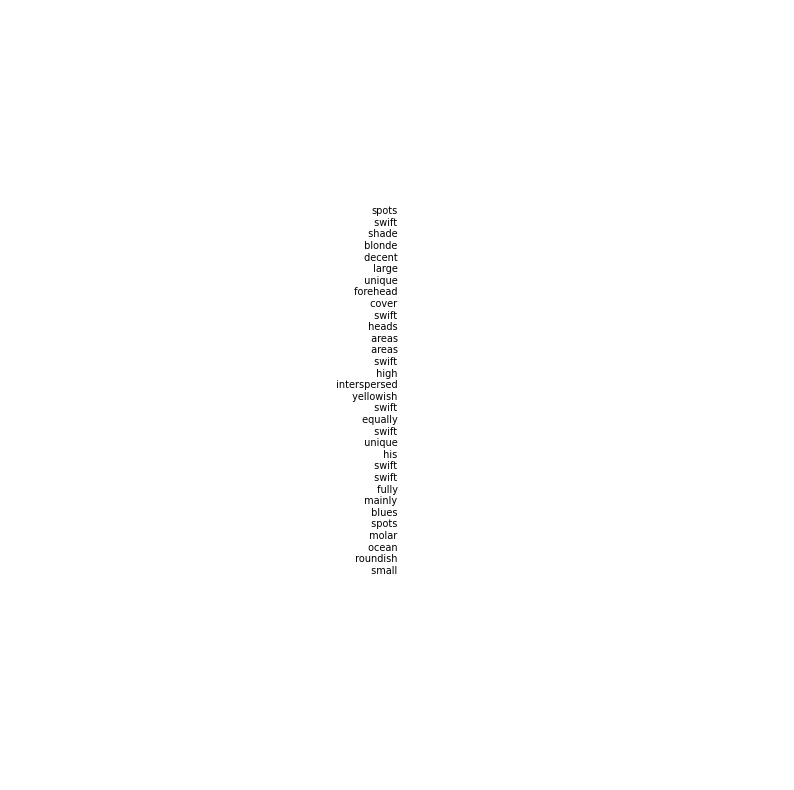

In [12]:

r = recon.reconstruction.squeeze()
numpimage = dataset.plot_text(r,(10,10))


AttributeError: 'FreeTypeFont' object has no attribute 'getsize_multiline'